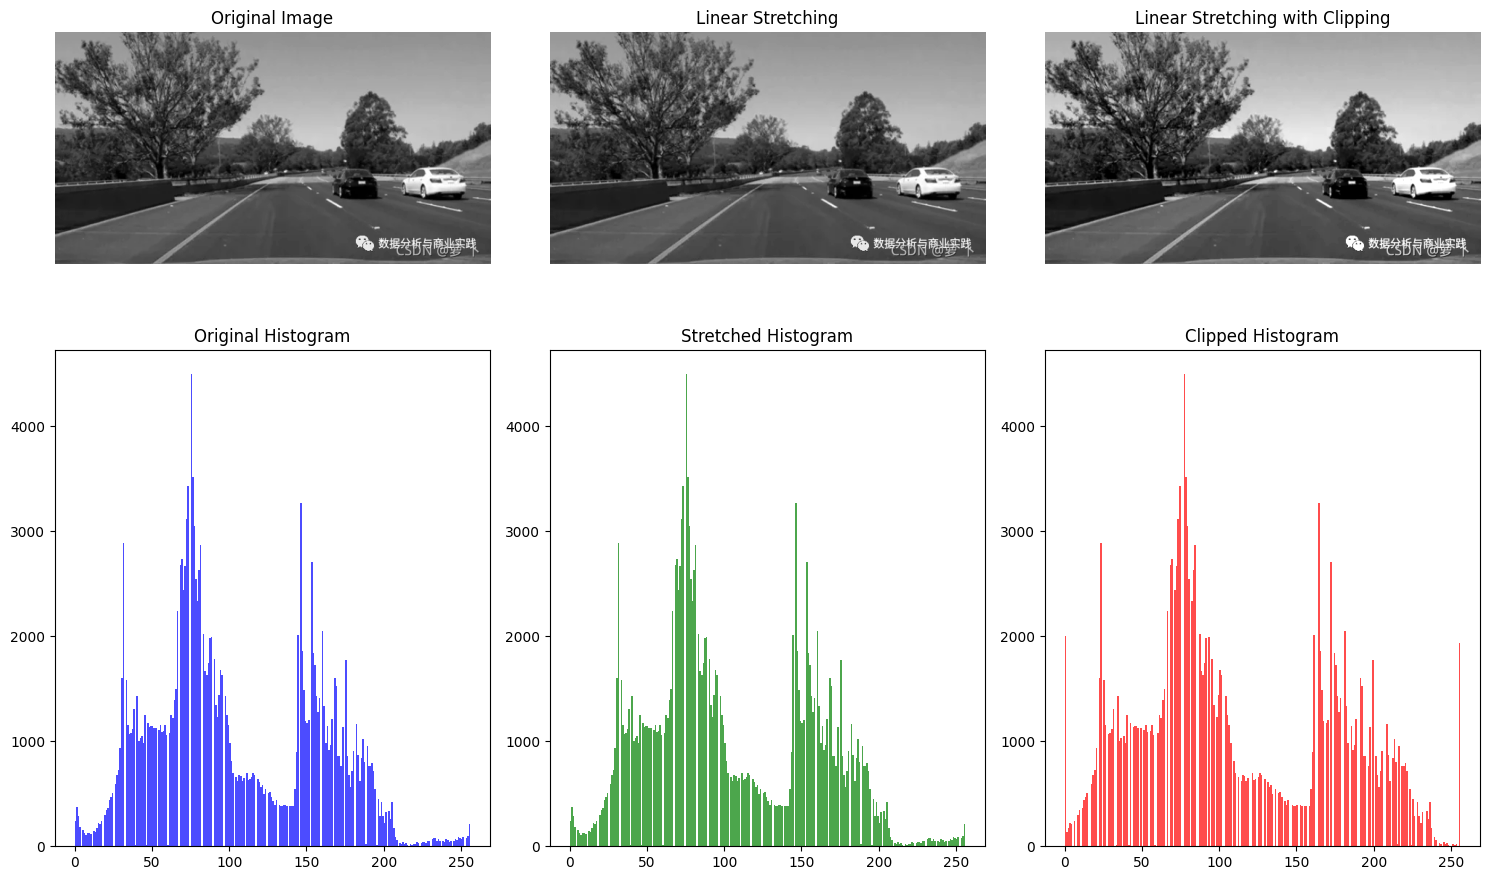

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def stander_strech(image):
    max_value = np.max(image)
    min_value = np.min(image)
    if max_value == min_value:
        return image
    image_float = image.astype(float)
    d = max_value - min_value
    m, n = image.shape
    d_min = np.ones((m, n)) * min_value
    output = (image_float - d_min) * 255 / d
    stretched_image_clip = np.clip(output, 0, 255)
    return stretched_image_clip.astype(np.uint8)

def percentile_strech(image, p):
    image_float = image.astype(float)
    d_low = np.percentile(image_float, p)
    d_high = np.percentile(image_float, (100 - p))
    if d_high == d_low:
        return image
    d = d_high - d_low
    m, n = image.shape
    d_low_matrix = np.ones((m, n)) * d_low
    output = (image_float - d_low_matrix) * 255 / d
    stretched_image_clip = np.clip(output, 0, 255) # d_low以下的像素值被设置为0，d_high以上的像素值被设置为255
    return stretched_image_clip.astype(np.uint8)

IMAGE_PATH = r"C:\ZC\HIT\Compulsory_Courses\CV\CV_lab\mine\lab1\data\grey_picture.png"

image = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
stretched_image = stander_strech(image)
p = 1
stretched_image_clip = percentile_strech(image, p)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2行3列
# 第一行：显示图片
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(stretched_image, cmap='gray')
axes[0, 1].set_title('Linear Stretching')
axes[0, 1].axis('off')

axes[0, 2].imshow(stretched_image_clip, cmap='gray')
axes[0, 2].set_title('Linear Stretching with Clipping')
axes[0, 2].axis('off')

# 第二行：显示直方图
axes[1, 0].hist(image.ravel(), bins=256, range=(0, 256), alpha=0.7, color='blue')
axes[1, 0].set_title('Original Histogram')

axes[1, 1].hist(stretched_image.ravel(), bins=256, range=(0, 256), alpha=0.7, color='green')
axes[1, 1].set_title('Stretched Histogram')

axes[1, 2].hist(stretched_image_clip.ravel(), bins=256, range=(0, 256), alpha=0.7, color='red')
axes[1, 2].set_title('Clipped Histogram')

plt.tight_layout()
plt.show()



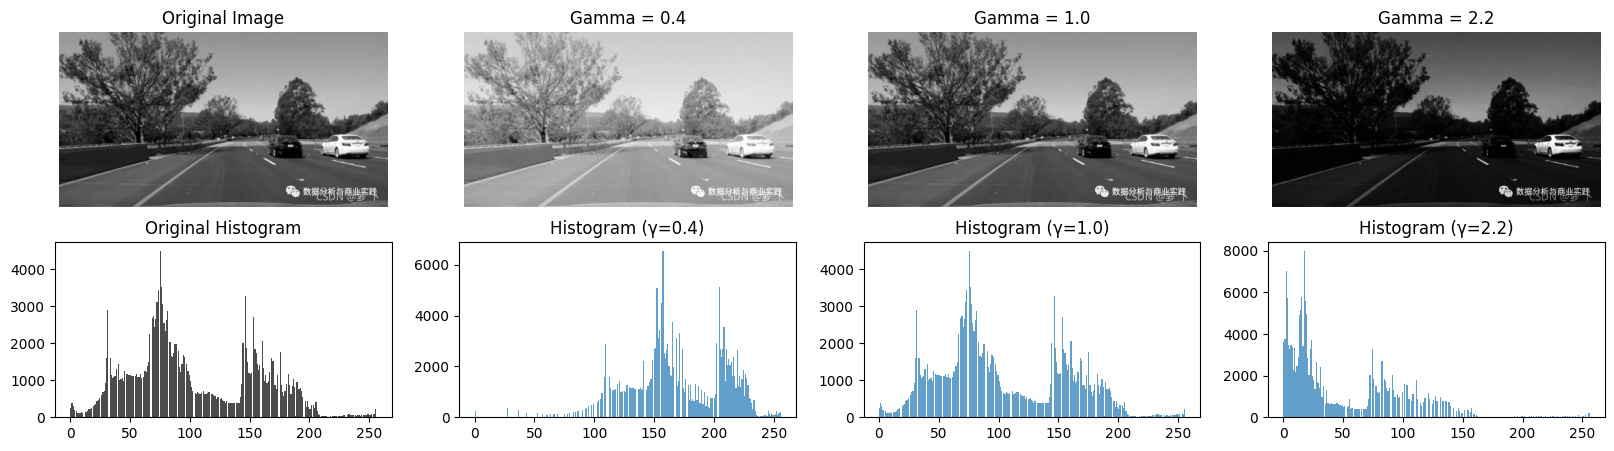

In [4]:
def gamma_correction(image, gamma):
    image_float = image.astype(float)
    normalized_image = image_float / 255.0
    corrected_image = np.power(normalized_image, gamma) * 255
    corrected_image_clip = np.clip(corrected_image, 0, 255)
    return corrected_image_clip.astype(np.uint8)

IMAGE_PATH = r"C:\ZC\HIT\Compulsory_Courses\CV\CV_lab\mine\lab1\data\grey_picture.png"
image = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
gamma = [0.4, 1.0, 2.2]
fig, axes = plt.subplots(2, 4, figsize=(20, 5))  
# 第一列：显示原图
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# 第二行第一列：原图直方图
axes[1, 0].hist(image.ravel(), bins=256, range=(0, 256), alpha=0.7, color='black')
axes[1, 0].set_title('Original Histogram')

# 然后循环从 i=0 开始，对应 gamma 列表，依次填入第 1、2、3 列（索引 1,2,3）
for i, g in enumerate(gamma):
    corrected_image = gamma_correction(image, g)
    axes[0][i+1].imshow(corrected_image, cmap='gray')
    axes[0][i+1].set_title(f'Gamma = {g}')
    axes[0][i+1].axis('off')
    
    axes[1][i+1].hist(corrected_image.ravel(), bins=256, range=(0, 256), alpha=0.7)
    axes[1][i+1].set_title(f'Histogram (γ={g})')



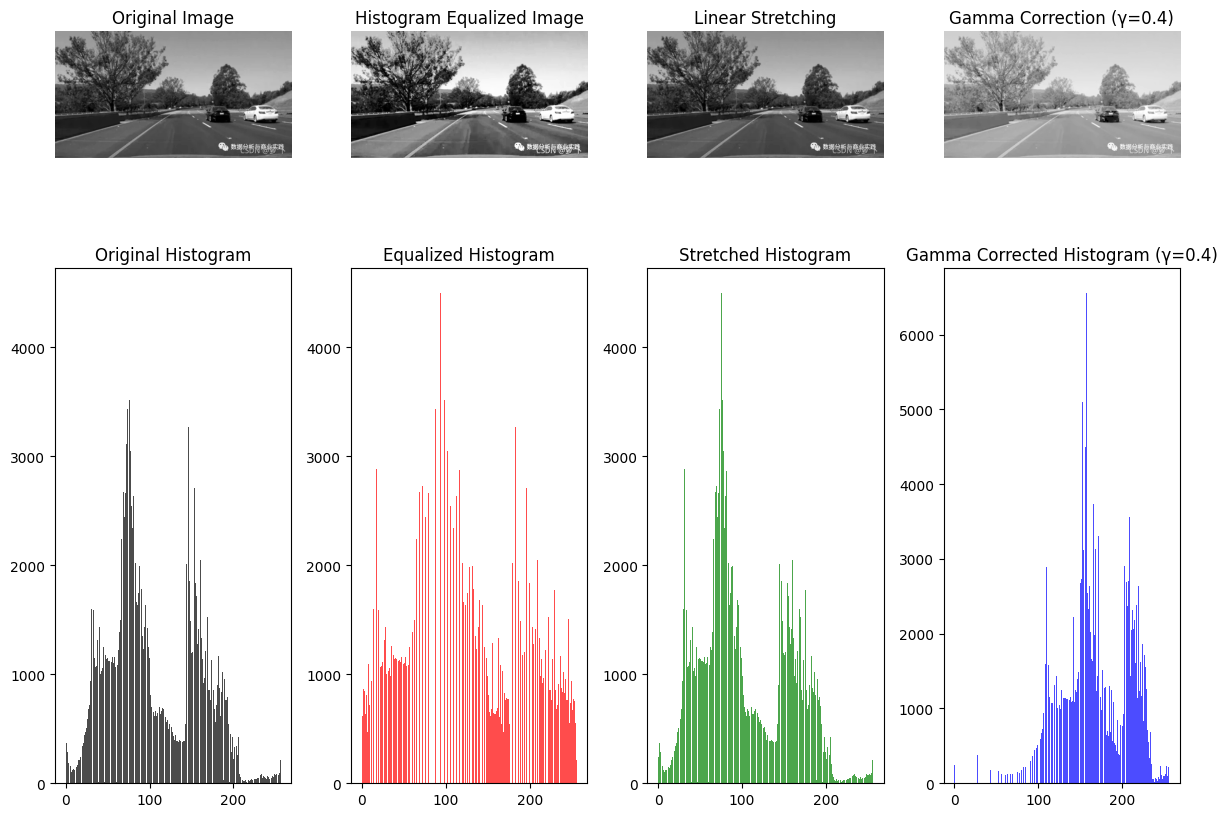

In [5]:
def histogram_equalization(image):
    histogram, _ = np.histogram(image.flatten(), bins=256, range=(0, 256))
    cdf = histogram.cumsum()
    cdf_LUT = np.floor(255 * cdf / cdf[-1])  # 归一化CDF并映射到[0, 255]
    equalized_image = cdf_LUT[image.flatten()]  # 使用LUT进行像素值映射
    return equalized_image.reshape(image.shape).astype(np.uint8)

IMAGE_PATH = r"C:\ZC\HIT\Compulsory_Courses\CV\CV_lab\mine\lab1\data\grey_picture.png"
image = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
equalized_image = histogram_equalization(image)
fig, axes = plt.subplots(2, 4, figsize=(12, 10))
# 第一列：显示原图
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# 第二行第一列：原图直方图
axes[1, 0].hist(image.ravel(), bins=256, range=(0, 256), alpha=0.7, color='black')
axes[1, 0].set_title('Original Histogram')
# 第二列：显示直方图均衡化后的图像
axes[0, 1].imshow(equalized_image, cmap='gray')
axes[0, 1].set_title('Histogram Equalized Image')
axes[0, 1].axis('off')
# 第二行第二列：直方图均衡化后的图像的直方图
axes[1, 1].hist(equalized_image.ravel(), bins=256, range=(0, 256), alpha=0.7, color='red')
axes[1, 1].set_title('Equalized Histogram')

# 第三列：显示线性拉伸后的图像
stretched_image = stander_strech(image)
axes[0, 2].imshow(stretched_image, cmap='gray')
axes[0, 2].set_title('Linear Stretching')
axes[0, 2].axis('off')
# 第二行第三列：线性拉伸后的图像的直方图
axes[1, 2].hist(stretched_image.ravel(), bins=256, range=(0, 256), alpha=0.7, color='green')
axes[1, 2].set_title('Stretched Histogram')
# 第四列：显示gamma校验后的图像
gamma = 0.4
gamma_corrected_image = gamma_correction(image, gamma)
axes[0, 3].imshow(gamma_corrected_image, cmap='gray')
axes[0, 3].set_title(f'Gamma Correction (γ={gamma})')
axes[0, 3].axis('off')
# 第二行第四列：gamma校验后的图像的直方图
axes[1, 3].hist(gamma_corrected_image.ravel(), bins=256, range=(0, 256), alpha=0.7, color='blue')
axes[1, 3].set_title(f'Gamma Corrected Histogram (γ={gamma})')
plt.tight_layout()
plt.show()
